# 06 — Analytics longitudinal : baseline, scoring, anomalie, tendances

Une session HRV isolée a peu de valeur. C'est l'**évolution dans le temps** qui permet
de détecter la fatigue, le surentraînement ou les progrès d'adaptation.

Ce notebook couvre :
1. **Baseline personnelle** — construction progressive, window = 7 sessions
2. **Score de readiness** — relatif à la baseline (neutre = 50)
3. **Détection d'anomalies** — z-score, déviation absolue, rolling median
4. **Tendances** — régression linéaire sur la série RMSSD
5. **Dashboard longitudinal** — heatmap sessions × métriques

**Prérequis :** sessions importées en base via le notebook 02.

In [1]:
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path("../.env"))

import matplotlib.pyplot as plt

from cardiolab.analytics import (
    Baseline,
    detect_rmssd_anomaly,
    readiness_score_multi,
    readiness_score_oura,
    trend_rmssd,
)
from cardiolab.database import HRVRepository
from cardiolab.labels import LABELS_FR
from cardiolab.visualization.dashboard_plots import plot_longitudinal_heatmap
from cardiolab.visualization.resting_plots import (
    plot_resting_evolution_rolling,
)

USER_ID_TEST = "demo-user"
print("✓  OK")

✓  OK


## 1 — Charger l'historique et construire la baseline

La **baseline** est construite *progressivement* : la session N est scorée contre
les sessions 1…N-1. La première session retourne toujours 50 (neutre) car il n'y a
pas encore de référence personnelle.

In [2]:
with HRVRepository.from_env() as repo:
    history = repo.load_features(USER_ID_TEST)

if not history:
    print("⚠️  Aucune session — exécutez d'abord le notebook 02")
else:
    baseline = Baseline()
    scores_oura = []
    scores_multi = []
    rolling_rmssd = []
    dates = []

    for feat in history:
        sc_oura = readiness_score_oura(feat, baseline)
        sc_multi = readiness_score_multi(feat, baseline)

        scores_oura.append(sc_oura)
        scores_multi.append(sc_multi)
        rolling_rmssd.append(baseline.mean_rmssd())
        dates.append(str(feat.date))
        feat.score = sc_oura

        baseline.history.append(feat)

    print(
        f"{len(history)} sessions | "
        f"Score moyen Oura : {sum(scores_oura) / len(scores_oura):.0f}/100 | "
        f"Score moyen multi : {sum(scores_multi) / len(scores_multi):.0f}/100"
    )

    print(f"\n{'Date':<12} {'RMSSD':>8} {'Oura':>7} {'Multi':>7}")
    print("-" * 38)
    for feat, sc_o, sc_m in zip(history, scores_oura, scores_multi, strict=False):
        print(
            f"  {str(feat.date):<10}  {feat.rmssd:>6.1f} ms  "
            f"{sc_o:>5.0f}/100  {sc_m:>5.0f}/100"
        )

6 sessions | Score moyen Oura : 53/100 | Score moyen multi : 60/100

Date            RMSSD    Oura   Multi
--------------------------------------
  2026-04-24    78.5 ms     50/100     50/100
  2026-04-25    51.8 ms     37/100     56/100
  2026-04-26    53.5 ms     38/100     55/100
  2026-04-27    52.6 ms     51/100     60/100
  2026-04-28    59.9 ms     60/100     62/100
  2026-04-30    81.9 ms     83/100     76/100


## 2 — Détection d'anomalies

Une **anomalie** est une session dont le RMSSD dévie significativement de la normale
personnelle. Trois méthodes disponibles :
- `zscore` — déviation standard (sensible aux outliers)
- `simple` — % d'écart à la moyenne (intuitif)
- `rolling` — médiane glissante (robuste)

In [3]:
if history and len(history) >= 3:
    print("Détection d'anomalies (méthode z-score) :")
    print(f"{'Date':<12} {'RMSSD':>8} {'Anomalie':>10} {'Z-score':>10}")
    print("-" * 46)

    baseline_all = Baseline.from_features(history)
    for feat in history:
        result = detect_rmssd_anomaly(feat, baseline_all, method="zscore")
        status = result.get("status", "")
        if status in ("insufficient_data", "no_variability"):
            flag = f"  {status}"
            z_str = "     —"
        else:
            is_anomaly = status in ("low", "high", "low_severe", "high_severe")
            flag = "⚠️  OUI" if is_anomaly else "  non"
            z_str = f"{result['z']:>+10.2f}"
        print(f"  {str(feat.date):<10}  {feat.rmssd:>6.1f} ms  {flag:>10}  {z_str}")
elif history:
    print("⚠️  Trop peu de sessions pour la détection d'anomalies (min 3)")

Détection d'anomalies (méthode z-score) :
Date            RMSSD   Anomalie    Z-score
----------------------------------------------
  2026-04-24    78.5 ms         non       +1.24
  2026-04-25    51.8 ms         non       -0.90
  2026-04-26    53.5 ms         non       -0.76
  2026-04-27    52.6 ms         non       -0.84
  2026-04-28    59.9 ms         non       -0.25
  2026-04-30    81.9 ms         non       +1.52


## 3 — Analyse de tendance

La **tendance** sur les 7 dernières sessions indique si le RMSSD est en train
d'augmenter (adaptation positive), de stagner ou de décliner (fatigue cumulative).

In [4]:
if history and len(history) >= 5:  # trend_rmssd requiert min 5 sessions
    baseline_trend = Baseline.from_features(history)
    trend = trend_rmssd(baseline_trend)

    if "status" in trend:
        print(f"⚠️  {trend['status']}")
    else:
        direction = trend["trend"]
        slope = trend["slope"]

        print(f"Tendance RMSSD (7 dernières sessions) : {direction}")
        print(f"  Pente    : {slope:+.3f} ms/session")

        interp = {
            "increasing": "↑  RMSSD en hausse — adaptation positive, récupération OK",
            "stable": "→  RMSSD stable — maintien du niveau de forme",
            "decreasing": "↓  RMSSD en baisse — possible fatigue cumulative ou stress",
        }.get(direction, direction)
        print(f"\n  {interp}")
elif history:
    print("⚠️  Trop peu de sessions pour l'analyse de tendance (min 5)")

Tendance RMSSD (7 dernières sessions) : increasing
  Pente    : +1.163 ms/session

  ↑  RMSSD en hausse — adaptation positive, récupération OK


## 4 — Visualisation avec RMSSD rolling

Le **RMSSD rolling** est la médiane des 7 dernières sessions : il filtre les
fluctuations journalières et révèle la tendance de fond.

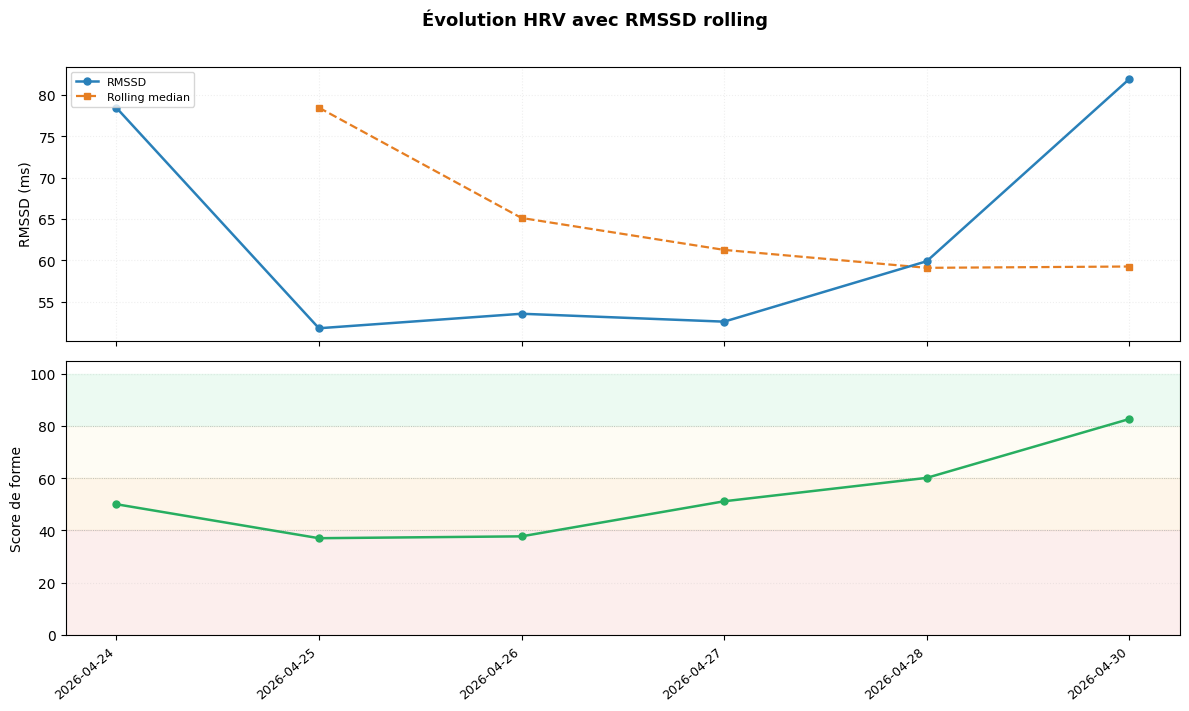

In [5]:
if history:
    fig = plot_resting_evolution_rolling(
        history,
        scores_oura,
        rolling_rmssd,
        session_labels=dates,
        labels=LABELS_FR,
        title="Évolution HRV avec RMSSD rolling",
    )
    plt.show()

## 5 — Heatmap longitudinale

Vue d'ensemble : sessions × métriques normalisées [0–1]. Les cellules grisées
indiquent des données manquantes.

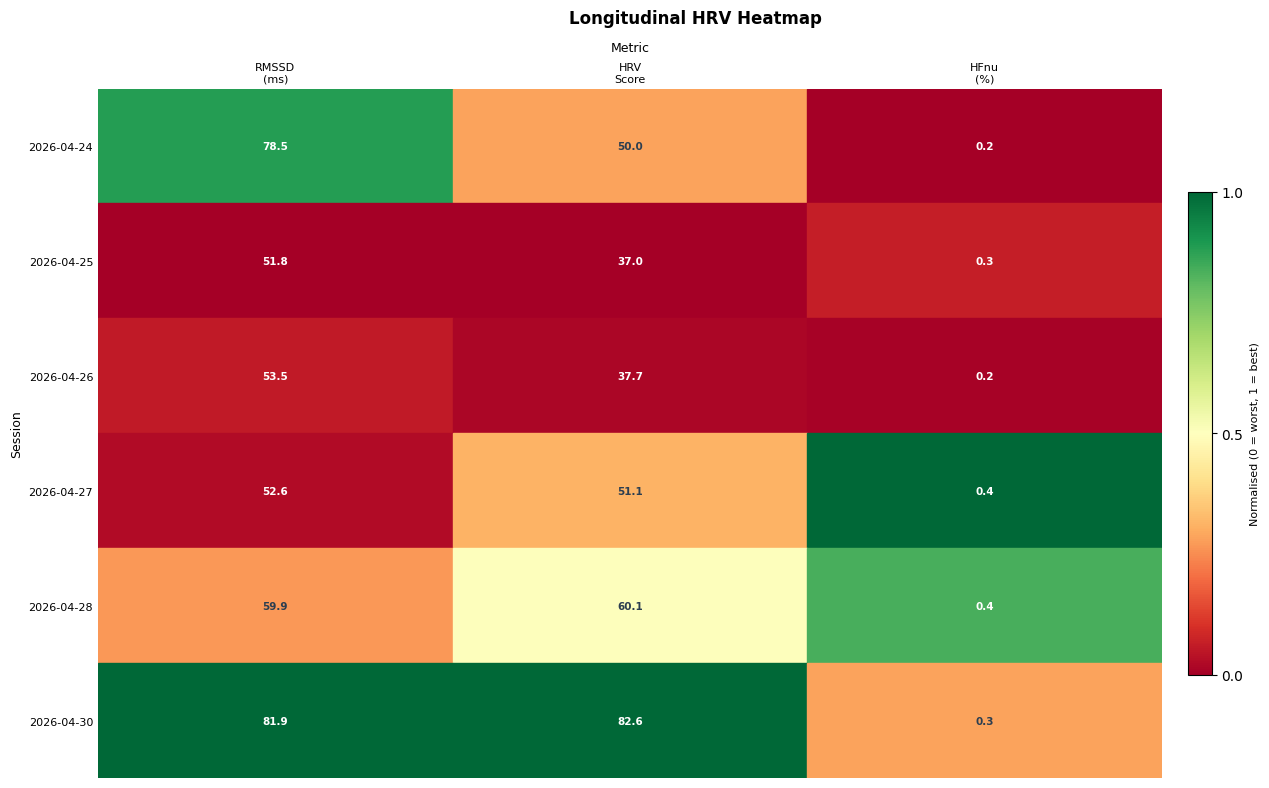

In [6]:
if history:
    fig = plot_longitudinal_heatmap(
        history,
        session_labels=dates,
    )
    plt.show()